In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.interpolate import make_interp_spline, BSpline

In [5]:
plt.rcParams['axes.facecolor'] = "#1f1f1f"    
plt.rcParams['figure.facecolor'] = "#1f1f1f"      
plt.rcParams['grid.color'] = '#777777'         
plt.rcParams['grid.linestyle'] = '--'         
plt.rcParams['grid.linewidth'] = 0.5            
plt.rcParams['grid.alpha'] = 0.8
plt.rcParams['font.size'] = 16                 
plt.rcParams['xtick.color'] = '#aaaaaa'     
plt.rcParams['ytick.color'] = '#aaaaaa'         
plt.rcParams['axes.labelcolor'] = '#aaaaaa'    
plt.rcParams['axes.titlecolor'] = '#aaaaaa'
plt.rcParams['legend.labelcolor'] = '#aaaaaa' 

In [6]:
fs = 10000
tau = 1/fs
x = np.tile(np.repeat(np.array([0,1]),128),20)
t = np.linspace(0, tau*len(x), len(x))
x_fft = np.abs(fft(x))
x_fft /= max(x_fft)
freq_x = fftfreq(len(x), d=t[1]-t[0])

Дифференцирующая цепь

In [36]:
T_dev_taud = 1/26.6
diff_a = np.array([1, -1])
diff_b = np.array([0, np.exp(-T_dev_taud)])
y_diff = np.zeros_like(x)
for i in range(1,len(y_diff)):
    y_diff[i] = x[i]*diff_a[0] + x[i-1]*diff_a[1] + y_diff[i-1]*diff_b[1]
print(f"Коэффициенты ak: {diff_a}\nКоэффициенты bk: {diff_b}")

Коэффициенты ak: [ 1 -1]
Коэффициенты bk: [0.        0.9631039]


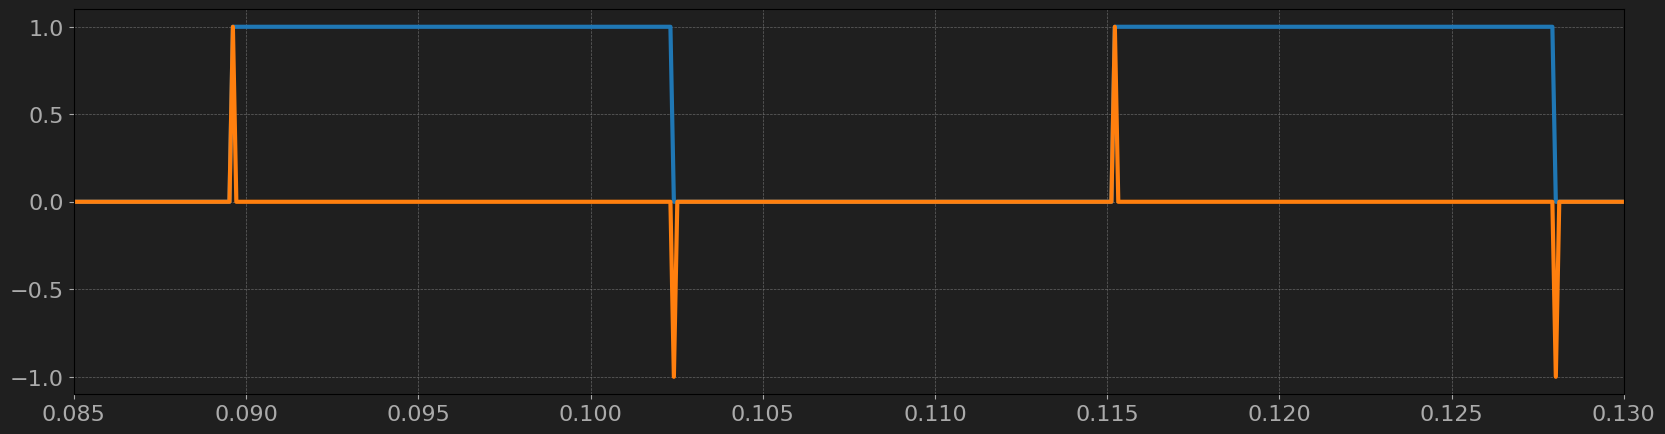

In [32]:
plt.figure(figsize=(20,5))
plt.plot(t, x, linewidth=3)
plt.plot(t, y_diff, linewidth=3)
# plt.xlim(750,4500)
plt.xlim(850*tau,1300*tau)
plt.grid(1)

In [9]:
freq_x = fftfreq(len(x), d=t[1]-t[0])
y_diff_fft = np.abs(fft(y_diff))
y_diff_fft /= max(np.abs(fft(x)))
freq_y_diff = fftfreq(len(y_diff), d=t[1]-t[0])


C:\Users\Ira\AppData\Local\Temp\ipykernel_19316\285145923.py:4: RuntimeWarning: divide by zero encountered in divide
  plt.stem(freq_x, (y_diff_fft/x_fft))


59.83268537289298


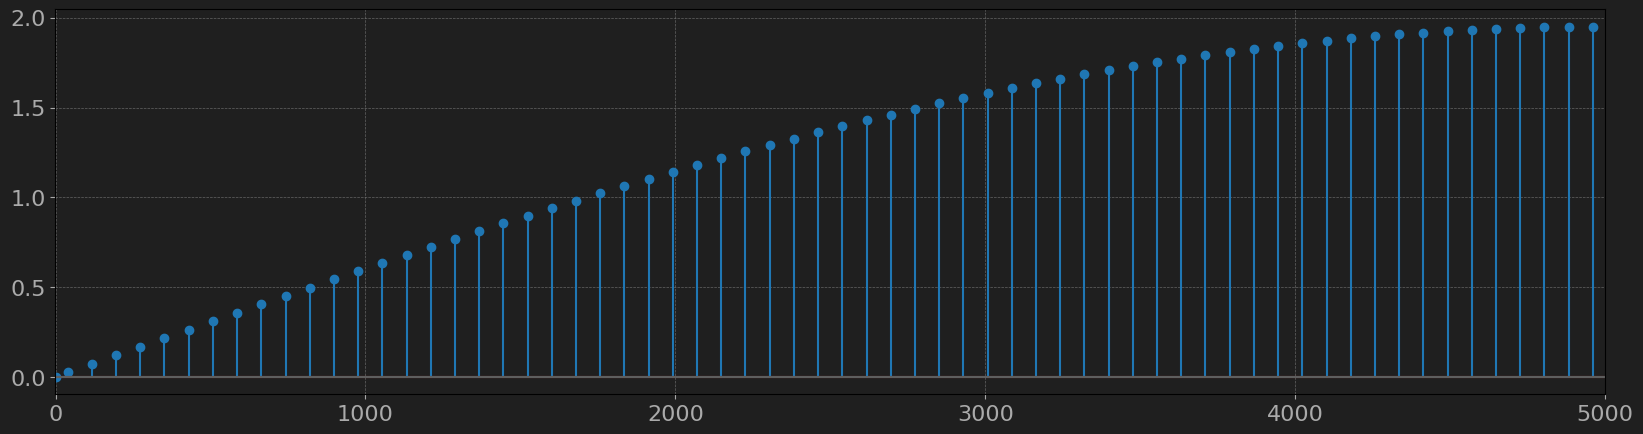

In [34]:
plt.figure(figsize=(20,5))
# plt.plot(freq_y_diff, y_diff_fft, linewidth=1)
# plt.stem(freq_x, x_fft)
plt.stem(freq_x, (y_diff_fft/x_fft))
plt.xlim(-1, 5*1e3)
plt.axhline(y=0, color="#5E5E5E", linewidth=1.5)
plt.grid(1)
print(1/(2*np.pi*(1/(T_dev_taud/tau))))

Интегрирующая цепь

In [38]:
T_dev_taui = 1/1.46
int_a = np.zeros(7)
for i in range(1,len(int_a)):
    int_a[i] = np.exp(-i*T_dev_taui)*(np.exp(T_dev_taui)-1)
y_int = np.zeros(len(x))
for i in range(6,len(y_int)):
    y_int[i] = x[i-1]*int_a[1] + x[i-2]*int_a[2] + x[i-3]*int_a[3] + x[i-4]*int_a[4] + x[i-5]*int_a[5] + x[i-6]*int_a[6]
print(f"Коэффициенты ak: {int_a}")

Коэффициенты ak: [0.         0.49587524 0.24998299 0.12602261 0.06353112 0.03202761
 0.01614591]


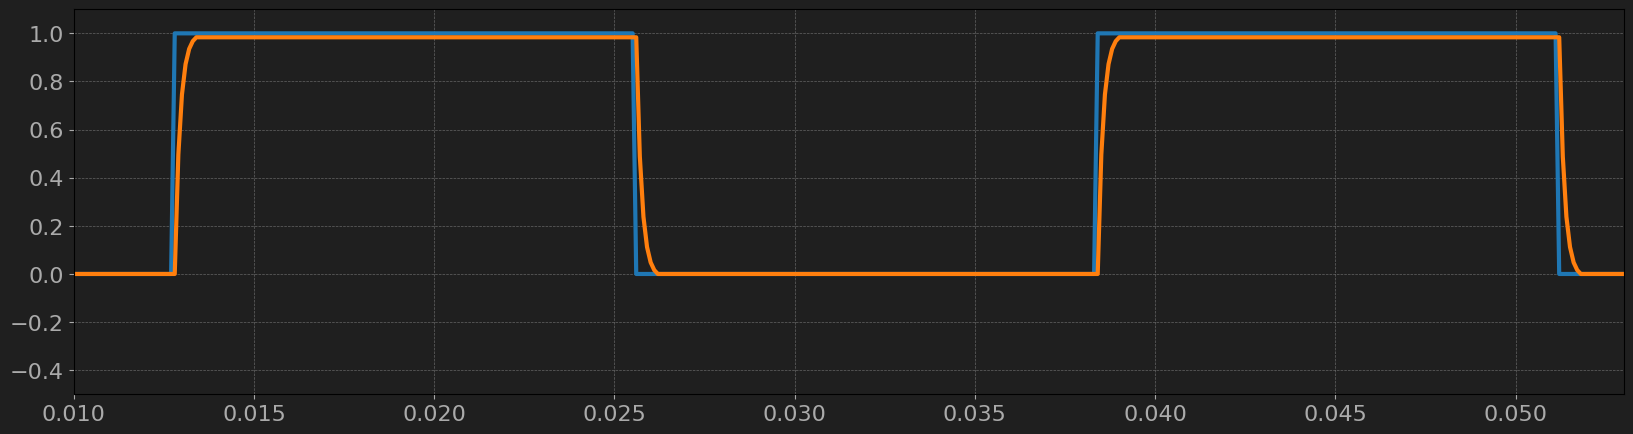

In [12]:
plt.figure(figsize=(20,5))
plt.plot(t, x, linewidth=3)
plt.plot(t, y_int, linewidth=3)
plt.xlim(100*tau,530*tau)
plt.ylim(-0.5, 1.1)
plt.grid(1)

In [13]:
y_int_fft = np.abs(fft(y_int))
y_int_fft /= max(np.abs(fft(x)))
freq_y_int = fftfreq(len(y_int), d=t[1]-t[0])



C:\Users\Ira\AppData\Local\Temp\ipykernel_19316\4013848196.py:4: RuntimeWarning: divide by zero encountered in divide
  plt.stem(freq_x, (y_int_fft/x_fft))


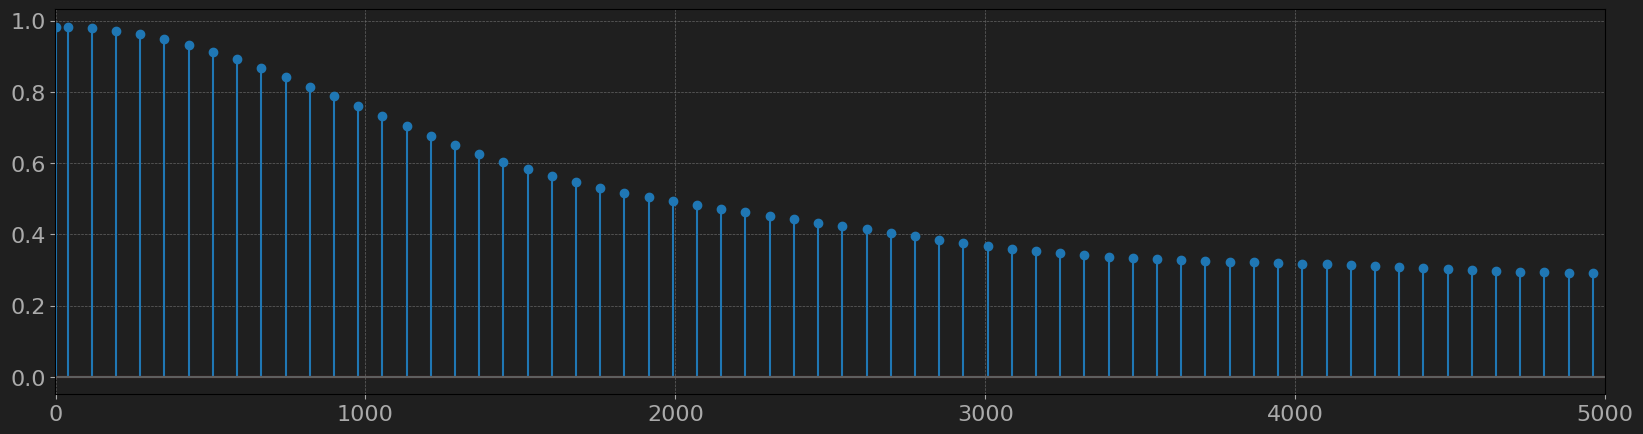

In [33]:
plt.figure(figsize=(20,5))
# plt.plot(freq_y_diff, y_diff_fft, linewidth=1)
# plt.stem(freq_x, x_fft)
plt.stem(freq_x, (y_int_fft/x_fft))
plt.xlim(-1, 5*1e3)
plt.axhline(y=0, color="#5E5E5E", linewidth=1.5)
plt.grid(1)

Резонатор

In [39]:
f0 = 2340
B = 115
omega_norm = 2*np.pi*f0/fs
alpha = np.pi*B/fs
res_a = 1
res_b = np.array([0, 2*np.exp(-alpha)*np.cos(omega_norm), -np.exp(-2*alpha)])
y_res = np.zeros(len(x))
for i in range(2,len(y_int)):
    y_res[i] = x[i]*res_a + y_res[i-1]*res_b[1] + y_res[i-2]*res_b[2]
print(f"Коэффициенты ak: {res_a}\nКоэффициенты bk: {res_b}")

Коэффициенты ak: 1
Коэффициенты bk: [ 0.          0.19360106 -0.93029212]


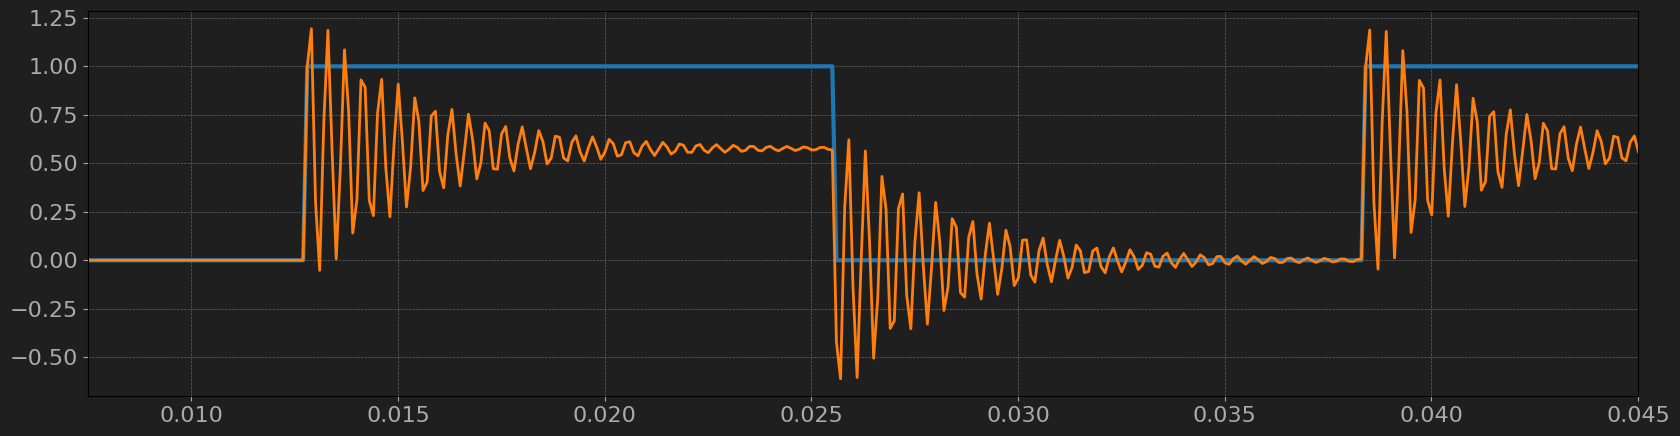

In [16]:
plt.figure(figsize=(20,5))
plt.plot(t, x, linewidth=3)
plt.plot(t,  y_res, linewidth=2)
plt.xlim(75*tau,450*tau)
plt.grid(1)

In [17]:
y_res_fft = np.abs(fft(y_res))
y_res_fft /= max(np.abs(fft(x)))
freq_y_res = fftfreq(len(y_res), d=t[1]-t[0])

C:\Users\Ira\AppData\Local\Temp\ipykernel_19316\1730452927.py:4: RuntimeWarning: divide by zero encountered in divide
  plt.stem(freq_x, (y_res_fft/x_fft)/2)


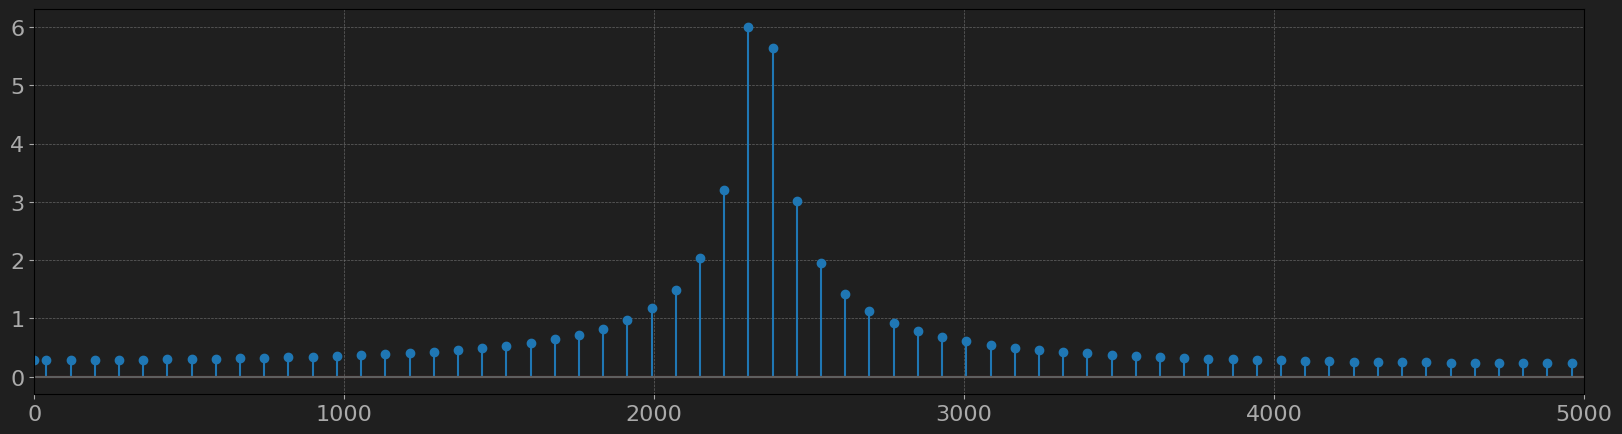

In [40]:
plt.figure(figsize=(20,5))
# plt.plot(freq_y_diff, y_diff_fft, linewidth=1)
# plt.stem(freq_x, x_fft)
plt.stem(freq_x, (y_res_fft/x_fft)/2)
plt.xlim(-1, 5*1e3)
plt.axhline(y=0, color="#5E5E5E", linewidth=1.5)
plt.grid(1)

Режектор

Баттерворд

In [42]:
# f00 = np.arange(0, 1e5, 1)
# f_bp = 2*fs*np.tan(np.pi*f00/fs)
# plt.plot(f00, f_bp)
# plt.ylim(0, 1e5)
# # plt.xlim(0, 3e3)
# plt.grid(1)

In [44]:
fc = 2340
f1 = 2*fc  # частота, накоторой затухание L
L = 13
N = np.ceil(np.log10(2*(np.pow(10, L/20))-1)/(2*np.log10(f1/fc)))
print(f"Порядок фильтра: {N}")
C1 = np.sqrt(2)*(fs/fc/np.pi)
C2 = np.pow((fs/fc/np.pi),2)
C3 = (C1+C2+1)
bat_a = np.array([1/C3, 2/C3, 1/C3])
bat_b = np.array([0, 2*(C2-1)/C3, (C1-C2-1)/C3])
y_bat = np.zeros(len(x))
for i in range(2,len(y_int)):
    y_bat[i] = x[i]*bat_a[0] + x[i-1]*bat_a[1] + x[i-2]*bat_a[2] + y_bat[i-1]*bat_b[1] + y_bat[i-2]*bat_b[2]
print(f"Коэффициенты ak: {bat_a}\nКоэффициенты bk: {bat_b}")

Порядок фильтра: 2.0
Коэффициенты ak: [0.2094607 0.4189214 0.2094607]
Коэффициенты bk: [ 0.          0.35625597 -0.19409878]


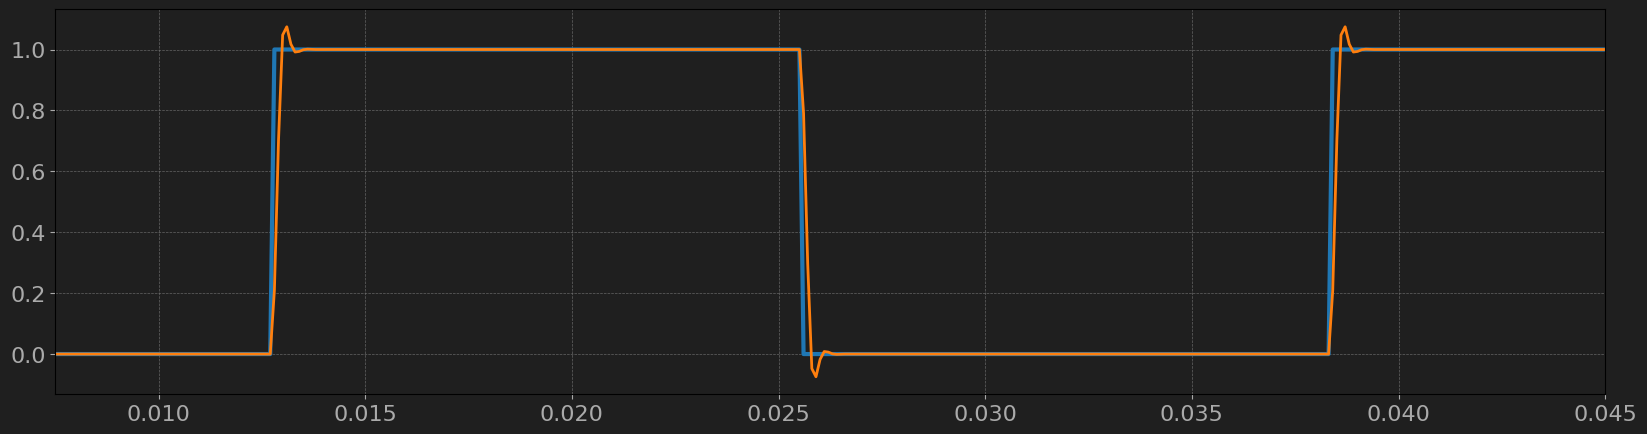

In [21]:
plt.figure(figsize=(20,5))
plt.plot(t, x, linewidth=3)
plt.plot(t,  y_bat, linewidth=2)
plt.xlim(75*tau,450*tau)
plt.grid(1)

In [22]:
y_bat_fft = np.abs(fft(y_bat))
y_bat_fft /= max(np.abs(fft(x)))
freq_y_bat = fftfreq(len(y_bat), d=t[1]-t[0])

C:\Users\Ira\AppData\Local\Temp\ipykernel_19316\4005594035.py:5: RuntimeWarning: divide by zero encountered in divide
  plt.stem(freq_x, 20*np.log10(np.abs((y_bat_fft/x_fft))), bottom=-45)


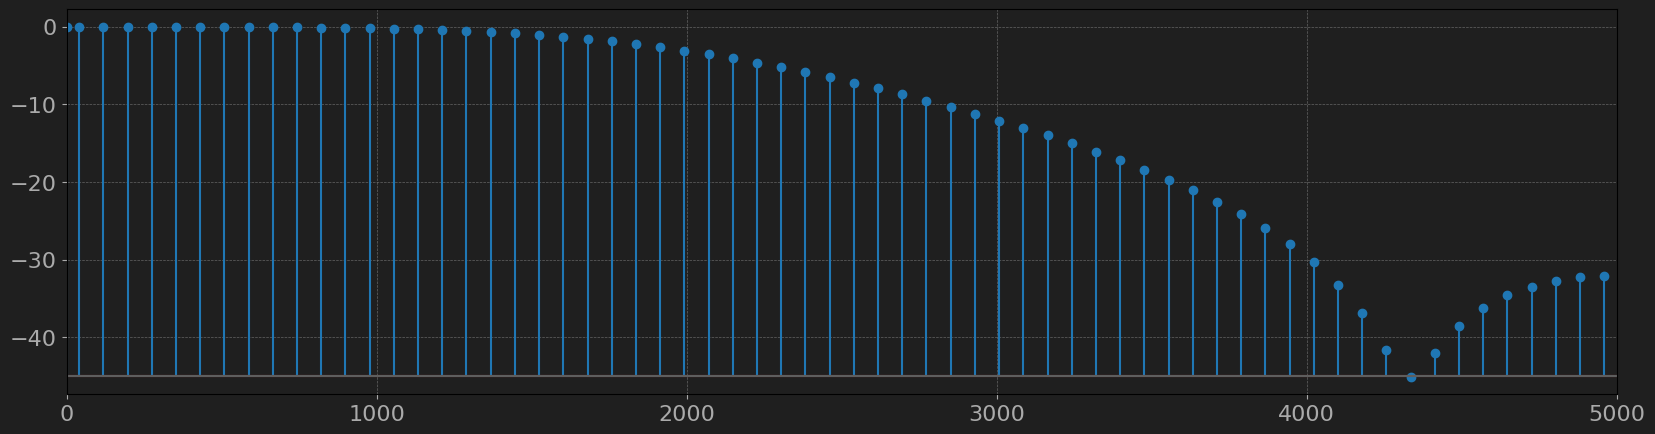

In [63]:
plt.figure(figsize=(20,5))
# plt.plot(freq_y_diff, y_diff_fft, linewidth=1)
# plt.stem(freq_x, x_fft)
# plt.stem(freq_x, (y_bat_fft/x_fft))
plt.stem(freq_x, 20*np.log10(np.abs((y_bat_fft/x_fft))), bottom=-45)
plt.xlim(-1, 5*1e3)
plt.axhline(y=-45, color="#5E5E5E", linewidth=1.5)
plt.grid(1)

In [68]:
fp = 2340
B = 115
omega_norm = 2*np.pi*fp/fs
b_norm = 2*np.pi*B/fs
k1 = -np.cos(omega_norm)
k2 = (1-np.sin(b_norm))/np.cos(b_norm)
y_rej = np.zeros(len(x))
y_rej2 = np.zeros(len(x))
for i in range(1,len(y_rej)):
    y_rej[i] = x[i]*k1 + x[i-1] + y_rej[i-1]*k1
for i in range(1,len(y_rej2)):
    y_rej2[i] = y_rej[i]*k2 + y_rej[i-1] + y_rej2[i-1]*k2
print(f"Коэффициент k1: {k1}\nКоэффициент k2: {k2}")

Коэффициент k1: -0.10036171485121491
Коэффициент k2: 0.9302335560864372


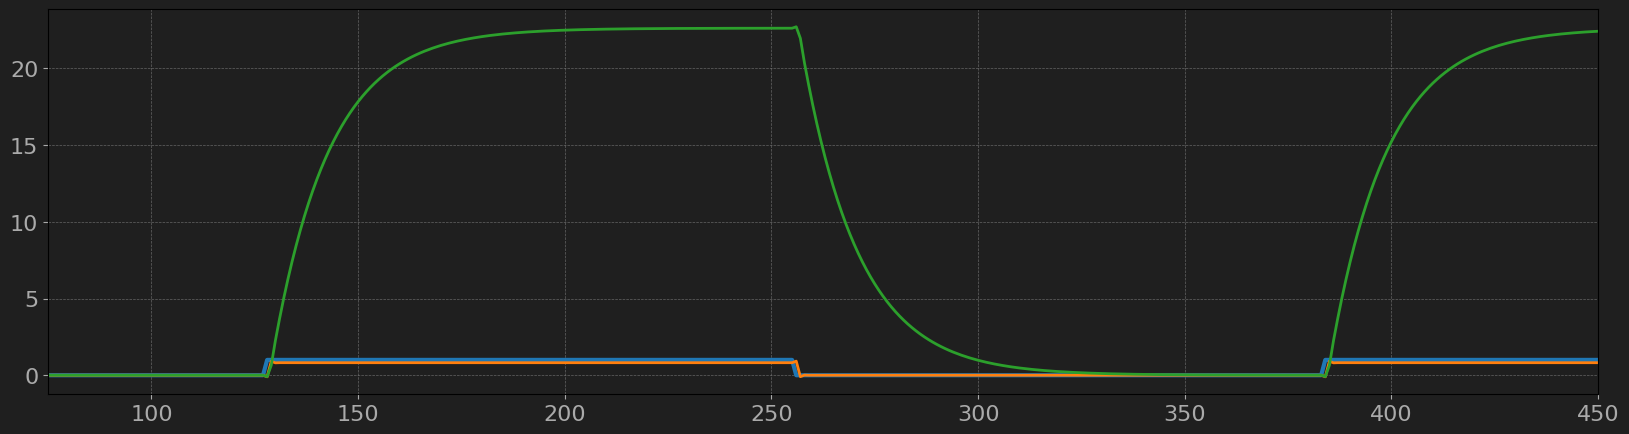

In [67]:
plt.figure(figsize=(20,5))
plt.plot(x, linewidth=3)
plt.plot(y_rej, lw=2)
plt.plot(y_rej2, linewidth=2)
plt.xlim(75,450)
plt.grid(1)